# Sensitivities as k-space kernels

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/FiRMLAB-Pisa/mrtoeplitz/blob/main/examples/coil_kernels.ipynb)

`CoilKernels`: holding a receive array's sensitivities as small centred
k-space kernels and expanding one coil at a time — sound exactly when the maps
are band-limited, which is measured here against three banks from BART.

In [1]:
try:
    import mrtoeplitz  # noqa: F401
except ImportError:
    %pip install -q "mrtoeplitz[nufft]" matplotlib finufft

In [2]:
from pathlib import Path
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
import torch

import mrtoeplitz as mt

# Three sensitivity banks, all produced by BART rather than by hand, and
# regenerated by examples/make_coil_maps.sh:
#
#   simulated : bart coils --H2D8C, its own analytic 8-channel head coil
#   espirit   : bart ecalib, eigenvector-normalised
#   nlinv     : bart nlinv, whose Sobolev weighting is a band limit
local = Path("coil_maps.npz")
if not local.exists():
    urlretrieve(
        "https://raw.githubusercontent.com/FiRMLAB-Pisa/mrtoeplitz/main/"
        "examples/coil_maps.npz",
        local,
    )
loaded = np.load(local)
banks = {
    name: torch.as_tensor(loaded[name])
    for name in ("simulated", "espirit", "nlinv")
}
image = torch.as_tensor(loaded["object"]).to(torch.complex64)
n = image.shape[-1]
print({name: tuple(bank.shape) for name, bank in banks.items()})

{'simulated': (8, 128, 128), 'espirit': (8, 128, 128), 'nlinv': (8, 128, 128)}


## Maps are the reconstruction

A SENSE normal reads one coil at a time. It never needs the whole bank at
once, but the bank is what gets stored: at 320 cubed with 48 channels, complex
single-precision maps are 12.6 GB, which on most cards *is* the
reconstruction.

Holding small centred k-space kernels instead, and expanding one coil when the
apply asks for it, trades the bank for a single map in flight — which the
apply already holds. This is riesling's low-memory mode, and it is sound
exactly when the map is band-limited.

So the question is not whether the idea works but which maps it works on, and
that is a measurement rather than an argument.

In [3]:
sides = (4, 8, 12, 16, 24, 32, 48, 64)
errors = {
    name: [float(mt.CoilKernels.from_maps(bank, (k, k)).truncation_error(bank))
           for k in sides]
    for name, bank in banks.items()
}

print(f"{'kernel side':>12}" + "".join(f"{name:>12}" for name in banks))
for index, k in enumerate(sides):
    print(f"{k:>12}" + "".join(f"{errors[name][index]:>12.1e}" for name in banks))

 kernel side   simulated     espirit       nlinv
           4     3.4e-01     3.3e-01     2.4e-01
           8     2.3e-01     2.0e-01     2.5e-02
          12     1.9e-01     1.4e-01     8.6e-05
          16     1.6e-01     1.1e-01     1.6e-07
          24     1.3e-01     6.2e-02     1.4e-07
          32     1.1e-01     3.7e-02     1.4e-07
          48     8.8e-02     1.4e-02     1.4e-07
          64     7.2e-02     5.8e-03     1.4e-07


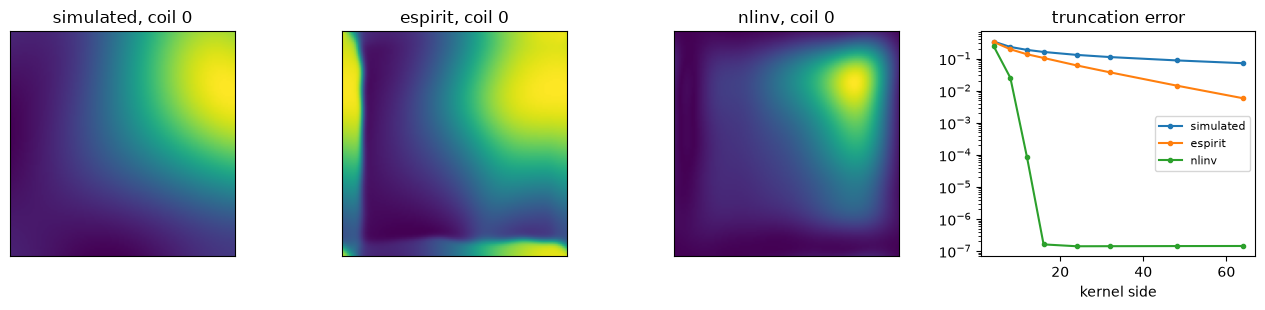

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(13, 3.2))
for axis, (name, bank) in zip(axes[:3], banks.items()):
    axis.imshow(np.abs(bank[0].numpy()), cmap="viridis")
    axis.set_title(f"{name}, coil 0")
    axis.set_xticks([])
    axis.set_yticks([])

for name in banks:
    axes[3].semilogy(sides, errors[name], "o-", markersize=3, label=name)
axes[3].set_title("truncation error")
axes[3].set_xlabel("kernel side")
axes[3].legend(fontsize=8)
fig.tight_layout()

In [5]:
# Written only when the notebook runs inside a clone, and it is what the
# README shows -- so the figure in the README is always this cell's output.
figures = Path("figures")
if figures.is_dir():
    fig.savefig(figures / "coil_kernels.png", dpi=110, bbox_inches="tight")

Three banks, six orders of magnitude between them.

**NLINV's maps are band-limited by construction** — its Sobolev weighting *is*
a band limit — and a 16-cell kernel reproduces them to 1e-07. BART already
stores them as k-space coefficients for the same reason.

**ESPIRiT's are not.** The `|m| = 1` eigenvector normalisation puts a hard
edge in the image, and a hard edge has broad k-space support: truncating it is
not band-limiting but ringing.

**Nor is a realistic simulated array.** BART's own analytic head coil falls off
like a field from a conductor, whose spectrum decays as a power law rather than
compactly — its error is still 7e-02 with the kernel at half the grid. That is
worth knowing precisely because it is the map a simulation study would use.

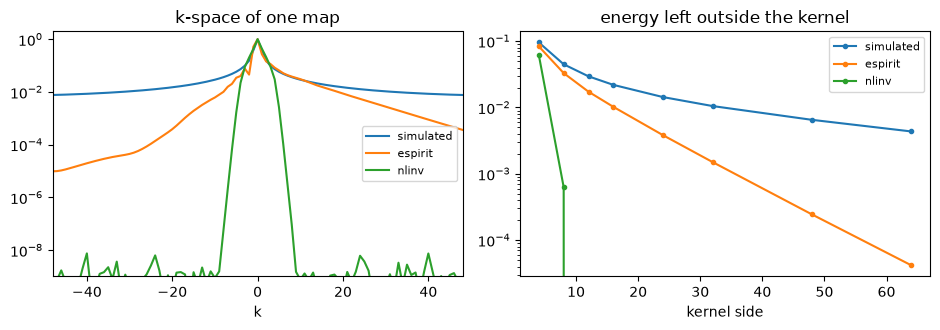

In [6]:
def spectrum(bank):
    axes_ = (-2, -1)
    return np.abs(
        np.fft.fftshift(
            np.fft.fftn(np.fft.ifftshift(bank[0].numpy(), axes=axes_), axes=axes_),
            axes=axes_,
        )
    )


fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4))
middle = n // 2
for name, bank in banks.items():
    profile = spectrum(bank)[middle]
    axes[0].semilogy(np.arange(n) - middle, profile / profile.max(), label=name)
axes[0].set_xlim(-48, 48)
axes[0].set_ylim(1e-9, 2)
axes[0].set_title("k-space of one map")
axes[0].set_xlabel("k")
axes[0].legend(fontsize=8)

for name, bank in banks.items():
    power = spectrum(bank) ** 2
    kept = [
        power[middle - k // 2 : middle - k // 2 + k,
              middle - k // 2 : middle - k // 2 + k].sum() / power.sum()
        for k in sides
    ]
    axes[1].semilogy(sides, 1.0 - np.array(kept), "o-", markersize=3, label=name)
axes[1].set_title("energy left outside the kernel")
axes[1].set_xlabel("kernel side")
axes[1].legend(fontsize=8)
fig.tight_layout()

## In the normal operator

`apply_sense` takes either a tensor or a `CoilKernels`, and nothing else in a
solve changes: every consumer of a bank here reads it one coil batch at a
time.

In [7]:
# The bank the design is for: NLINV's, at the side its own curve says is
# enough.
side = 16
kernels = mt.CoilKernels.from_maps(banks["nlinv"], (side, side))
print(kernels)

angles = np.linspace(0, np.pi, 96, endpoint=False)
radius = np.linspace(-0.5, 0.5, 192, endpoint=False)
trajectory = np.stack(
    [np.outer(np.cos(angles), radius), np.outer(np.sin(angles), radius)], axis=-1
).astype(np.float32)
density = np.linalg.norm(trajectory, axis=-1).astype(np.float32)
kernel = mt.scalar_kernel(trajectory, (n, n), density=density)

through_maps = mt.apply_sense(kernel, image[None, None], banks["nlinv"])
through_kernels = mt.apply_sense(kernel, image[None, None], kernels)
agreement = float((through_maps - through_kernels).norm() / through_maps.norm())
print(f"SENSE normal through maps and through kernels agree to {agreement:.1e}")

CoilKernels(shape=(8, 128, 128), kernel_shape=(16, 16), compression=64.0x)


SENSE normal through maps and through kernels agree to 1.6e-07


## Where it matters

The kernel side is set by how smooth the sensitivity is, not by the image, so
the saving grows with the volume — for the maps it is sound on.

In [8]:
print(f"{'grid':>18}  {'maps':>10}  {'kernels':>11}   ratio")
for shape, coils in (((128, 128), 8), ((256, 256, 256), 32), ((320, 320, 320), 48)):
    dense = coils * int(np.prod(shape)) * 8
    kept = coils * side ** len(shape) * 8
    label = "x".join(str(s) for s in shape) + f" x {coils}"
    print(f"{label:>18}  {dense / 2**30:8.2f} GB  {kept / 2**20:9.2f} MB  "
          f"{dense / kept:6.0f}x")

              grid        maps      kernels   ratio
       128x128 x 8      0.00 GB       0.02 MB      64x
  256x256x256 x 32      4.00 GB       1.00 MB    4096x
  320x320x320 x 48     11.72 GB       1.50 MB    8000x
